# Seaborn Diamonds 데이터셋을 이용한 TensorFlow/Keras 회귀 모델

이 노트북은 오직 **TensorFlow/Keras**와 기본 라이브러리(Pandas, NumPy, Seaborn)만을 사용하여 다이아몬드 가격(`price`)을 예측하는 딥러닝 모델을 구축하고 평가합니다. (Scikit-learn 등 다른 머신러닝 라이브러리는 사용하지 않습니다.)

In [ ]:
# 셀 1: 라이브러리 임포트
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)

In [ ]:
# 셀 2: 데이터 로드 및 탐색
df = sns.load_dataset('diamonds')
print(df.head())
print("\n데이터셋 정보:")
print(df.info())

In [ ]:
# 셀 3: 데이터 전처리 (원핫 인코딩 및 정규화)
# 1. 범주형 변수 원핫 인코딩 (cut, color, clarity)
df = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True, dtype=float)

# 2. 특성과 타겟(price) 분리
X = df.drop(columns=['price']).values.astype(np.float32)
y = df['price'].values.astype(np.float32)

# 3. 수치형/원핫 컬럼에 대한 표준화(Standardization) 스케일링 (순수 TF/Numpy 구현)
mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1.0  # 0으로 나누기 방지
X = (X - mean) / std

# 4. 학습/테스트 데이터 분할 (순수 Numpy 사용)
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(len(X) * 0.8)

train_idx, test_idx = indices[:train_size], indices[train_size:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
y_test_flat = y_test.flatten()

print(f"훈련 데이터 크기: {X_train.shape}, 테스트 데이터 크기: {X_test.shape}")

In [ ]:
# 셀 4: Keras 모델 구조 정의
def create_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # 가격 예측을 위한 선형 출력층
    ])
    
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

model = create_model(X_train.shape[1])
model.summary()

In [ ]:
# 셀 5: 모델 학습 (Training)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

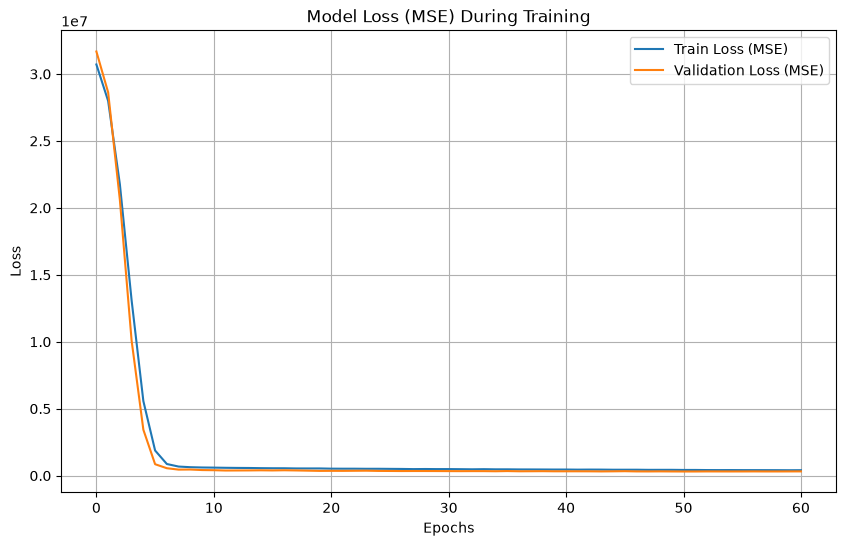

In [11]:
# 셀 5-1: 학습 손실(Loss) 차트 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss (MSE) During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# 셀 6: 모델 평가 (Evaluation)
test_loss, test_mae, test_rmse = model.evaluate(X_test, y_test, verbose=0)

print(f"Test MAE (Mean Absolute Error): ${test_mae:.2f}")
print(f"Test RMSE (Root Mean Squared Error): ${test_rmse:.2f}")

Test MAE (Mean Absolute Error): $298.24
Test RMSE (Root Mean Squared Error): $548.39


 62/338 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step

338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


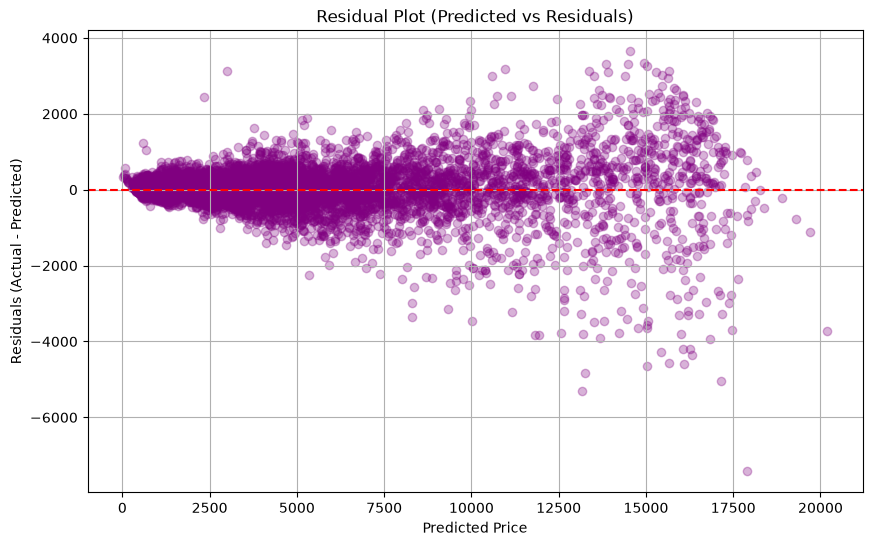

In [13]:
# 셀 7: 잔차(Residual) 그래프 시각화
import matplotlib.pyplot as plt

# 테스트 데이터에 대한 예측값 생성
y_pred = model.predict(X_test).flatten()
residuals = y_test.flatten() - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Plot (Predicted vs Residuals)')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()